# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# The file lands in /content when you upload it in Colab, and that's also the
# working directory, so just the filename works.
df = pd.read_csv("listings.csv.gz")

print("City: Denver, CO (Inside Airbnb, scraped 2026-06-30)")
print("Shape:", df.shape)
df.head()

City: Denver, CO (Inside Airbnb, scraped 2026-06-30)
Shape: (4939, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,360,https://www.airbnb.com/rooms/360,20260630053644,2026-06-30,city scrape,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,NaN,https://a0.muscache.com/pictures/monet/Select-...,666,...,4.99,4.98,4.90,2017-BFN-0002177,NaN,1,1,0,0,1.94
1,364,https://www.airbnb.com/rooms/364,20260630053644,2026-07-02,previous scrape,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of ...",NaN,https://a0.muscache.com/pictures/11766413/a2c5...,783,...,4.96,4.65,4.71,NaN,NaN,1,1,0,0,0.42
2,592,https://www.airbnb.com/rooms/592,20260630053644,2026-06-30,city scrape,private,This room is in the basement. It does not hav...,NaN,https://a0.muscache.com/pictures/ba522ff9-84c9...,933,...,4.96,4.84,4.88,2021-BFN-0000578,NaN,1,0,1,0,1.05
3,686,https://www.airbnb.com/rooms/686,20260630053644,2026-06-30,city scrape,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG...,NaN,https://a0.muscache.com/pictures/108112/e6d5d3...,990,...,4.91,4.87,4.82,NaN,NaN,1,0,1,0,1.16
4,1940,https://www.airbnb.com/rooms/1940,20260630053644,2026-06-30,city scrape,"Baker Studio Pet-friendly, Walkable, Patio",Private studio retreat in a charming historic ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,2150,...,4.99,4.90,4.90,2018-BFN-0002596,NaN,2,2,0,0,2.42


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

47 of 90 columns have missing values
13 columns are completely empty


,missing,percent
neighbourhood_group_cleansed,4939,100.0
host_acceptance_rate,4939,100.0
neighborhood_overview,4939,100.0
calendar_updated,4939,100.0
neighbourhood,4939,100.0
host_verifications,4939,100.0
host_total_listings_count,4939,100.0
host_neighbourhood,4939,100.0
host_thumbnail_url,4939,100.0
host_response_rate,4939,100.0


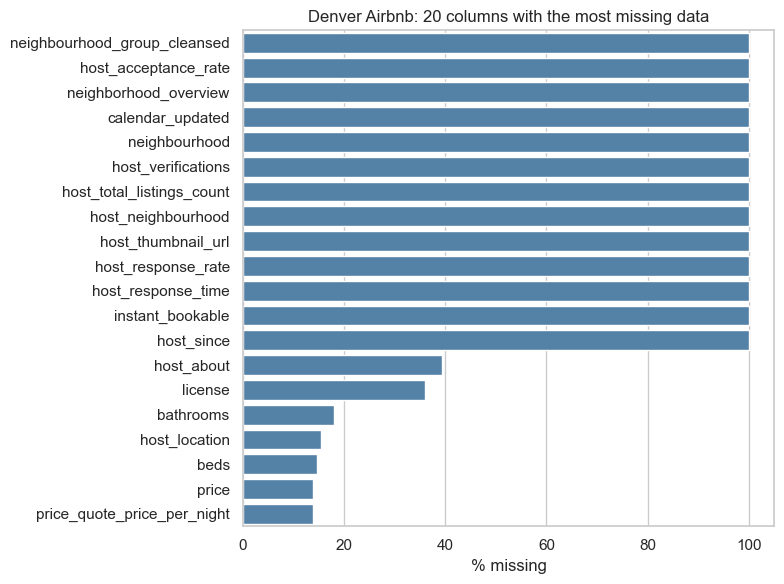

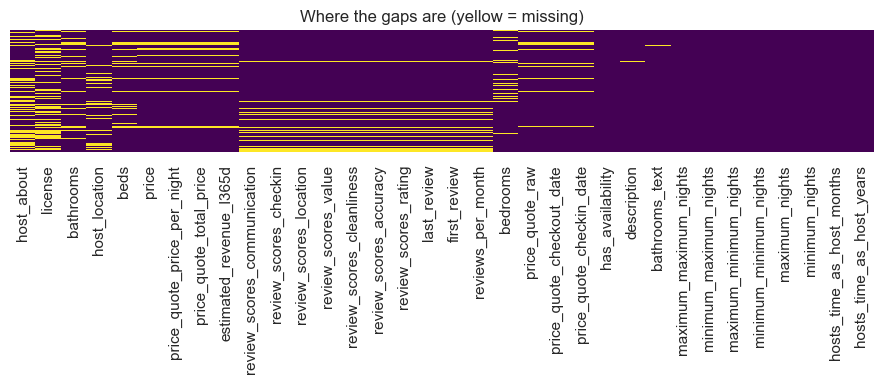

In [3]:
# How much of each column is missing?
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percent": (df.isnull().mean() * 100).round(1)
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)

print(f"{len(missing)} of {df.shape[1]} columns have missing values")
print(f"{(missing['percent'] == 100).sum()} columns are completely empty")
display(missing.head(20))

# The 20 worst columns
top = missing.head(20)
plt.figure(figsize=(8, 6))
sns.barplot(x=top["percent"], y=top.index, color="steelblue")
plt.xlabel("% missing")
plt.ylabel("")
plt.title("Denver Airbnb: 20 columns with the most missing data")
plt.tight_layout()
plt.show()

# Just the partly missing ones, to see if their gaps line up
partial = missing[missing["percent"] < 100].index
plt.figure(figsize=(9, 4))
sns.heatmap(df[partial].isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Where the gaps are (yellow = missing)")
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧

1. There's actually a 13 way tie for first. 13 columns in the Denver file are 100% empty, so they're all missing 4,939 values each, including `neighborhood_overview`, `host_since`, `host_response_time`, `host_response_rate` and `host_acceptance_rate`. If you skip those, the top 3 that are only partly missing are `host_about` at 39.4%, `license` at 35.9%, and `bathrooms` at 18.0%.

2. `license` is the one that would actually cause problems. Denver requires a short term rental license, so 1,773 listings with a blank one is either a compliance issue or just a gap in the scrape, and you'd need to know which before showing that to anybody. `bathrooms` and `beds` matter too since those drive pricing and search filters. The empty `host_response_time` and `host_acceptance_rate` columns hurt as well, because those are exactly what you'd use to judge how responsive a host is and there's nothing in them at all.

3. `host_about` is just free text hosts write about themselves, so 39% missing doesn't really cost you anything. The 13 empty ones are the easy call, since a column with zero values in it can't tell you anything no matter what you do with it.

## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [4]:
before = df.shape[1]

# Anything with no values at all can go.
empty_cols = df.columns[df.isnull().all()].tolist()

# Plus four that do have data but aren't useful here.
extra_cols = ["host_about", "host_name", "scrape_id", "source"]

print(f"{len(empty_cols)} completely empty columns:")
print(empty_cols)
print(f"\nPlus {len(extra_cols)}: {extra_cols}")

df = df.drop(columns=empty_cols + extra_cols)
print(f"\nColumns: {before} -> {df.shape[1]}")
df.info(verbose=False)

13 completely empty columns:
['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'instant_bookable']

Plus 4: ['host_about', 'host_name', 'scrape_id', 'source']

Columns: 90 -> 73
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Columns: 73 entries, id to reviews_per_month
dtypes: float64(26), int64(21), object(26)
memory usage: 2.8+ MB


### Reflection: 
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧

1. 17 of them, which took the file from 90 columns down to 73. That's the 13 completely empty ones plus `host_about`, `host_name`, `scrape_id` and `source`.

2. The 13 empty ones have literally nothing in them so there's nothing to lose. `host_about` is free text nobody's going to analyze. `host_name` is somebody's first name, which I don't need for a pricing question and probably shouldn't be passing around anyway. `scrape_id` and `source` are about how Inside Airbnb collected the file, not about the listing.

3. Mostly it's just clutter, since 90 columns is a lot to hand somebody. But the empty ones are the real risk, because a dashboard or a join can quietly pull in a column of nothing and you don't find out until a chart comes back blank. Keeping `host_name` is also a privacy thing I'd rather avoid once the file gets shared around.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [5]:
# bathrooms -> median. It's a physical thing about the property, most Denver
# listings really do have 1, and 18% missing is way too many rows to just drop.
print("bathrooms missing before:", df["bathrooms"].isnull().sum())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
print("bathrooms missing after: ", df["bathrooms"].isnull().sum())

# license -> "not listed". Denver requires a short term rental license, so a
# blank is really its own category and not just noise. Making it a label means
# it still groups properly in Assignment 7.
print("\nlicense missing before:", df["license"].isnull().sum())
df["license"] = df["license"].fillna("not listed")
print("license missing after: ", df["license"].isnull().sum())
display(df["license"].value_counts().head(3))

bathrooms missing before: 887
bathrooms missing after:  0

license missing before: 1773
license missing after:  0


license
not listed          1773
2023-BFN-0021376      40
2021-BFN-0001467      30
Name: count, dtype: int64

### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧

1. `bathrooms` and `license`.

2. `bathrooms` got the median, which is 1.0. It's a physical thing about the property, most Denver listings really do have one bathroom, and 887 missing is 18% of the file so dropping those rows would've cost way too much. `license` got the string "not listed" instead of staying blank. A missing license isn't really "no data", it's its own category, and turning it into a label means it still groups properly when I get to Assignment 7.

3. The median fill makes `bathrooms` look more uniform than it actually is, so any variation I filled in is basically made up. The license one is riskier though. "not listed" throws together listings that genuinely don't have a license and listings where the scraper just didn't catch one, and those are two very different things if somebody tries to use this for a compliance conversation.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Before: object
['$106.35', '$32.35', '$80.00']

After: float64


count      4251.00
mean        276.04
std        1753.13
min           7.38
25%         106.00
50%         176.45
75%         291.00
max      110616.60
Name: price, dtype: float64

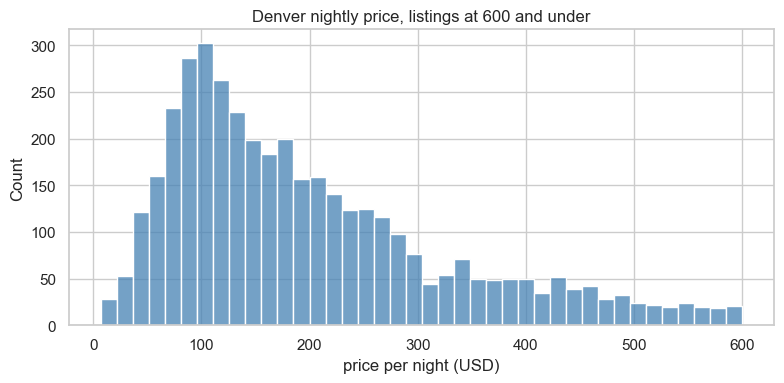

Listings above 2,000 a night: 9
Highest price in the file:    110616.6


In [6]:
# price comes in as text because of the dollar sign and the commas.
print("Before:", df["price"].dtype)
print(df["price"].dropna().head(3).tolist())

df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

print("\nAfter:", df["price"].dtype)
display(df["price"].describe().round(2))

# A few crazy values make the full range unreadable, so the chart stops at 600
# and the counts underneath say what's above it.
plt.figure(figsize=(8, 4))
sns.histplot(df.loc[df["price"] <= 600, "price"], bins=40, color="steelblue")
plt.xlabel("price per night (USD)")
plt.title("Denver nightly price, listings at 600 and under")
plt.tight_layout()
plt.show()

print("Listings above 2,000 a night:", (df["price"] > 2000).sum())
print("Highest price in the file:   ", df["price"].max())

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧

1. `price`.

2. It came in as text like `$106.35` because of the dollar sign, and the bigger numbers had commas in them too. I stripped both out with a regex and converted the column to a float.

3. Now you can actually do math on it. As text you couldn't take an average, sort by it, or plot it, which makes it useless for the pricing analysis this data is really for. Converting it also showed problems you couldn't see before, like a max of 110,616 a night and 9 listings over 2,000, which are almost definitely errors or placeholder prices somebody used to block their calendar.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates 
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs 
- Remove duplicates if found 

In [7]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate ids:      ", df["id"].duplicated().sum())
print("Unique ids:         ", df["id"].nunique(), "of", len(df), "rows")

df = df.drop_duplicates()
print("\nRows after dropping duplicates:", len(df))

# Not duplicate rows, but related: the same license number shows up on more than
# one listing, which is usually just one host running a few units.
licensed = df[df["license"] != "not listed"]
print("\nLicensed listings:                  ", len(licensed))
print("Distinct license numbers:           ", licensed["license"].nunique())
print("Licenses on more than one listing:  ", (licensed["license"].value_counts() > 1).sum())

Exact duplicate rows: 0
Duplicate ids:       0
Unique ids:          4939 of 4939 rows

Rows after dropping duplicates: 4939

Licensed listings:                   3166
Distinct license numbers:            2529
Licenses on more than one listing:   249


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧

1. No, and honestly that surprised me. Zero exact duplicate rows, and all 4,939 ids are unique.

2. There was nothing to drop, so this section turned into more of a check than a fix. I did find something related though. 3,166 listings have a license but only 2,529 of those numbers are distinct, so 249 licenses show up on more than one listing. Those aren't duplicate rows, it's just one host running a few units under the same license, so I left them alone.

3. If a listing showed up twice you'd double count its revenue and its availability, so any market size or occupancy number built on it would come out too high. Guests would also see the same place twice in search, which just makes the app look broken.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”) 
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP 
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP 

```





In [8]:
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

print("Saved cleaned_airbnb_data_6.csv")
print("Shape:", df.shape)

Saved cleaned_airbnb_data_6.csv
Shape: (4939, 73)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts? 
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information) 
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. Section 4, figuring out how to fill things. The coding part is one line. Deciding whether a blank license means "this host is unlicensed" or "the scraper missed it" is the actual hard part, and the data doesn't tell you which.

2. I kept `price` blank instead of filling it. 688 listings have no price, and the exact same 688 rows also have no estimated revenue. That tells me those listings never returned a quote, so filling in the median would've invented revenue for places that never made any. Leaving it blank felt more honest and Assignment 7 can decide what to do with it.

3. A pricing analyst can finally use `price` now that it's a number instead of text, so something like average nightly rate by neighborhood actually works. The license column being filled in also means the city or an app admin can group by licensed versus not listed and see that about a third of Denver listings don't have one attached.

4. The price outliers. A listing at 110,616 a night isn't real, and I'd want to know if those are typos, luxury placeholders, or hosts blocking their calendar with a fake number. I'd also dig into why 13 columns came back totally empty, since some of them like `host_response_rate` would be genuinely useful if they had data.

5. Both of my outcomes point at marketing analytics. The first one is about using Python to clean, visualize and model customer and campaign data well enough to build segments and judge whether a marketing effort actually worked. The second is about turning that into recommendations a marketing team could act on, while dealing with privacy, bias and the ethical limits of consumer data. This assignment hit both. Getting `price` out of text and deciding what to do with `license` is exactly the unglamorous step that has to happen before you can segment listings or compare performance across neighborhoods. The ethics side showed up too, since I dropped `host_name` specifically because it is a real person's name and there is no reason for it to travel with a file I hand to somebody else.